In [4]:
import numpy as np 
import matplotlib.pyplot as plt 
import scipy.integrate as integrate
from scipy.interpolate import PchipInterpolator
from scipy.integrate import simpson 
from scipy.special import lambertw

from __future__ import division, print_function, absolute_import

from numpy import cos, inf, zeros, array, exp, conj, nan, isnan, pi, sin, seterr
from numpy.lib.scimath import arcsin
import sys 

import torch #pytorch 

"""
Section 1: Importing n & k data for various materials and defining physical constants, wavelength ranges, etc.
"""

wl_array = []
n_W = []
k_W = []
n_AlN = []
k_AlN = []


nk_data = r"C:\School Stuff\UC Davis\Leite Lab\Data\W_AlN_Repro.txt"

with open(nk_data, "r") as f: #opens file = 'filename' in readmode --> 'r' and assigns this to a variable, f 
    header = f.readline() # reads 'one complete HORIZONTAL line' in the file and stores that information in the'header' variable, as this is usually header information. 
    for line in f:
        if not line.strip():
            continue # line.strip just removes any spaces, commas, etc. that are in the line, and then if the line is empty, it gets skipped over, and the next line is examined

        wl, W_n, AlN_n, W_k, AlN_k = line.split() #splits up the columns in the spreadsheet and assigns them to each respective variable, does it row by row or 'line by line'

        wl_array.append(float(wl)) #storing the wavelengths,
        n_W.append(float(W_n)) #storing n-data for W
        k_W.append(float(W_k)) #storing the k-data for W
        n_AlN.append(float(AlN_n)) #storing the n-data for AlN 
        k_AlN.append(float(AlN_k))

wl_array = np.array(wl_array)   #in units of nm 
n_W = np.array(n_W)
k_W = np.array(k_W)
n_AlN = np.array(n_AlN)
k_AlN = np.array(k_AlN)

mask = wl_array <= 3000         #Keeping only the values that are less than or equal to 3000 nm; but I might change this upper limit (07-28-26) 

wl_array = wl_array[mask]       #[nm] --> I typically have quantities in SI units so if I ever need to troublehshoot it's always worth checking the units here. 
n_W = n_W[mask]
k_W = k_W[mask]
n_AlN = n_AlN[mask]
k_AlN = k_AlN[mask]

n_complex_W = n_W + 1j * k_W        #Fully consructed complex refractive indices of thin film structure
n_complex_AlN = n_AlN + 1j * k_AlN

#physical constants 
h_J = 6.626 * 1E-34              #planck's constant in [Joule-seconds]
h_eV = 4.136 * 1E-15             #planck's constant in [eV-seconds]
c = 3*1E8                        #speed of light in [m/s] 
kb_J = 1.3806 * 1E-23            #boltzmann constant in  [Joule/Kelvin]
kb_eV = 8.6173 * 1E-5            #boltzmann constant in [eV/Kelvin] 
q = 1.602 * 1E-19                #charge of an electron in [Coulombs] 
b = 2.89771955 * 1E-3            #Wien's displacement constant [m * Kelvin] given here: https://en.wikipedia.org/wiki/Black-body_radiation#Planck's_law_of_black-body_radiation

In [2]:
#Section #2: Beginning the TMM Calculations to determine Emissivity of the AlN/W bilayer --> using TMM_fast package

"""
To calculate the emissivity you need to follow these steps:

1) Create your refractive index array/tensor. The dimensions of this tensor, N, are (S x L x W) where S = num_stacks, L = num_layers, and W = the wavelength array you want to calculate R, T, and A over 
    - Remember that 3D arrays are like this: (num_2D arrays that you want, row dimension(of 2D array), column dimension(of 2D array))

2) Create your thickness array. This has dimensions of (S x L) and is independent of wavelength. One caveat that I've noticed so far is that you can't do incoherent calculations. 

3) Check that all inputs are np.arrays or pytorch tensors 

4) Compute over s and p polarizations to simulate unpolarized light. 

"""

from tmm_fast import coh_tmm as tmm

wl = wl_array             #Not a necessary step, just did this to follow what was in the example on the tmm_fast page 

wl = torch.from_numpy(wl) #converting it from a numpy array --> pytorch tensor. the coh_tmm function requires that every parameter be the same format (i.e. all arrays or all tensors) 

theta = torch.zeros(1)    #Only calculating for normal incidence at the moment. If I wanted multiple angles then I'd use np.linspace or the pytorch equivalent. 
num_layers = 3            #I have three layers, Air/AlN/W where Air is semi-infinite, and W is usually semi-infinite. AlN ranges from 1 nm --> 1000nm 
num_stacks = 1000         #When I vary the thickness, each bilayer is its own unique stack. Thus, the number of layer thicknesses = number of stacks that I have. (stack == multilayer thin film) 

#create N (refractive index array/tensor) 
N = np.ones((num_stacks, num_layers, wl.shape[0]), dtype = 'complex')

"""
.shape[0] --> # of rows, .shape[1] --# of columns, and slicing at an index > 1 is accessing 3D or higher-dimensional parameters of the array. 

N = 3D array/tensor, where there are (wl.shape[0]) number of (num_stacks, num_layers) sized arrays

Since it's full of ones, if you have air as your first layer, the first column doesn't have to be modified. 
Everything else has to be modified to match your desired multilayer thin film(s) 
"""

for i in range(0, wl.shape[0]):           #start the range at 0 to include the 0th layer (air), and go up to wl.shape[0] --> index of substrate layer
    N[:, 1, i] = n_complex_AlN[i]         #fills in the second layer with wavelength dependent refractive indices of AlN                                   
    N[:, -1, i] = n_complex_W[i]          #fills in the last layer w/ wavelength dependent refractive indices of W                                       

   
N = torch.from_numpy(N)                   #converting this to a Torch Tensor



"""
def optical_thickness(lam, k):               #unitless quantity; This ends up not being used in this version of the code (08/04/26) 
    return (4 * np.pi * d_sub) * k / lam     #where k and lam are the imaginary part of the refractive index and the wavelength, respectively 

#for i in range(0, len(d_coating)): #inherently, this loop is kind of unnecessary because the whole package assumes that we're doing coherent calculations. If it was incoherent I'd have to use a different logic 
#for j, k in enumerate(k_W):    #because this loop basically says, "if it's transparent at ANY wavelength, then set the thickness for all wavelengths to be d_sub.          
    #if optical_thickness(wl_array[j], k) > 12:
        #T[i,2] = np.inf 
    #else:
        #T[i,2] = d_sub
"""

#Create thickness array

d_coating = np.arange(1,1001, 1)            #np.arange(a, b, step size) creates an array beginning at a --> up to b, but not including b. Indexing starts at 0
d_sub = 1E5                                 #if the optical thickness is NOT opaque then the substrate thickness is 10,000 nm (i.e. 0.1 mm) 
T = np.ones((num_stacks, num_layers))       #initializing the array, can use np.zeros, ones, etc. 

T[:,0] = np.inf                             #assigning the very first layer thickness to be infinite; because air is always going to be a semi-infinite layer if it's the very first layer. 

for i in range(0, len(d_coating)):
    T[i,1] = d_coating[i]

T[:,-1] = np.inf

T = torch.from_numpy(T)


#Calculating reflectivity. If it was transparent you'd have to set E = A = 1 - R - T. Otherwise, just set E = A = 1 - R 

tmm_s_results = tmm('s', N, T, theta, wl, device = 'cpu') #the outputs of this function are dictionaries. 
tmm_p_results = tmm('p', N, T, theta, wl, device = 'cpu') #The keys are 'r', 't', 'R', and 'T' with each having shape (num_stacks, theta.shape[0], and wl.shape[0])

R_avg = (tmm_s_results['R'] + tmm_p_results['R']) * 0.5   #average Reflectance over both polarizations 

emissivity = 1 - R_avg                                    #kirchoff's law of radiation 

emissivity_ALL = emissivity.numpy()                       #converting it back to a numpy array so that it can be plotted easily with matplotlib


C:\Users\bryan\AppData\Local\Programs\Python\Python313\Lib\site-packages\tmm_fast\vectorized_tmm_dispersive_multistack.py:152: UserWarning: Opacity warning. The imaginary part of the refractive index is clamped to 35i for numerical stability.
You might encounter problems with gradient computation...
  warn('Opacity warning. The imaginary part of the refractive index is clamped to 35i for numerical stability.\n'+


In [3]:
"""
Section #2.5: Functions for Blackbody Spectrum + for Computing Dual Junction Stuff 
"""

def lam_Bandgap(EG_eV):       #Returns Band gap wavelength in units of [m] 
    return h_eV * c / EG_eV   #Input MUST be in units of [eV]

def lam_BB_peak(Temperature): #From Wien's Displacement Law; this returns peak wavelength of the BB spectrum 
    return (b) / Temperature  #in units of [m] 

def EQE(lam, lam_Eg):                   #External Quantum Efficiency (Idealized) --> Step function assumes that lam is in nanometers 
    return np.where(lam < lam_Eg, 1, 0) #Output is Unitless, inputs must be in units of [nm] 

def BB_spectrum(lam, T):                #Blackbody Spectrum/Spectral Radiance: has units of W/m^3 if you input lam in [m] and T in [K] 
    numerator = (2 * h_J * c**2 )
    denominator = (lam)**5 * ( np.exp( (h_J * c) / (lam * kb_J * T) ) - 1 )
    return numerator/denominator   

def n_B(lam, T):                        #Blackbody Photon Spectral Radiance: has units of [s^-1 * m^3] if you input lam in [m] and T in [K] 
    numerator = (2 * c)                                                     #numerator is in [m/s]
    denominator = (lam)**4 * ( np.exp( (h_J * c) / (lam * kb_J * T) ) - 1 ) #denominator in [m^4]
    return numerator/denominator   

def P_derivative(J_L, J_0, V):          #Needed to calculate the maximum power point for a single cell 
    return (J_L + J_0) - (J_0) * np.exp(q * V / (kb_J * T_c)) * (1 + q * V / (kb_J * T_c))

def J(J_L, J_0, V):                     #Current-Density in units of [A/m^2] of the Tandem Cell 
    return J_L - J_0 * (np.exp(1 * V / (kb_eV * T_c)) - 1)
    #return J_L - J_0 * (np.exp(1 * V / (kb_eV * T_c))) #Declan uses this approximation in 02-20-25 Slides. 

def J_sc_approx(J_L, J_0):
    #return J_L - J_0 #approximate value, doesn't make a huge difference if you use this or the other return 
    return J_L

def P_cell_SJ_WCM2(wl_array, lam_Eg, emissivity, T_emitter, T_c): #Function for calculating cell power in [W/cm^2] for a single cell 

    n_B_array_LIGHT = n_B(wl_array, T_emitter)                       #the WL array in the argument must be in units of meters 
    n_B_array_DARK = n_B(wl_array, T_c)                          

    #Constructing the Ideal External Quantum Efficiency Function
    EQE_SF = EQE(wl_array * 1E9, lam_Eg * 1E9)                       #both things in the argument must be in units of nm; hence multiplication by 1E9 

    #Building the integrands 
    integrand_JL = q * np.pi * emissivity * n_B_array_LIGHT * EQE_SF #integrand of the light-induced current, it should have units of m^-3 * Amperes (C/s), 
                                                                     #integrating it will give A/m^2 which is appropriate for current density. 
                                                                     #emissivity_TOP, EQE_SF_TOP, and n_B_array_LIGHT_TOP, are all arrays of equal dimensions. 
                                                                     #since it's the top cell, the integration limits are from (lambda_min --> lambda_max) 
                                                                                    
    integrand_J0 = q * np.pi * n_B_array_DARK * EQE_SF               #integrand of the dark-current, [A/m^2] 

    #Performing the Integration to obtain J_L and J_0 
    J_L = simpson(integrand_JL, x=wl_array)                          #light-induced current density given in [A/m^2]

    J_0 = simpson(integrand_J0, x=wl_array)                          #dark-current density given in [A/m^2]
    
    #Creating J-V Curve and Grabbing P_max 
    V_oc = (np.log((J_L / J_0) + 1)) * kb_eV * T_c  #in units of Volts, the open circuit voltage (I = 0)

    V_vals = np.linspace(0, V_oc, 200)              #creates the array of possible voltage values for IV curve

    P_derivs = P_derivative(J_L, J_0, V_vals)       #calculates the derivatives of Power wrt Voltage 
    
    differences = np.abs(P_derivs - P_deriv_target) #apart of finding where the voltage that produces P_max is  
    
    idx = np.argmin(differences) 
    
    V_pmax = V_vals[idx]         #voltage that produes P_max 
    
    J_pmax = J(J_L, J_0, V_pmax) # Current-density in A/m^2 that produces P_max 
    
    P_max = J_pmax * V_pmax      # Maximum Cell Power in units of W/m^2 

    P_cell = P_max * 1E-4        # Maximum cell power in units of W/cm^2 

    return P_cell 
    

def P_cell_DJ_WCM2(wl_array_TOP, wl_array_BOT, lam_Eg_TOP, lam_Eg_BOT, emissivity_TOP, emissivity_BOT, T_emitter, T_c):
    """
             Function for finding P_Cell in [W/cm^2] of a Dual-Junction Setup without radiant coupling 
             n_B spectra for light(T_e) and dark(T_c), wavelengths of emitter spetrum
             emissivity --> scalar value or Array(must be same dimensions) 
             wl_array_BOT will be another array that gets initialized, from [lambda_Eg_Top, --> end of spectrum]) 
             ***** ALL WAVELENGTHS MUST BE INPUT IN [m] *****
    """

    #Constructing the Blackbody Spectral Photon Radiance Arrays for light & dark (for Top and Bottom)
    n_B_array_LIGHT_TOP = n_B(wl_array_TOP, T_emitter)                               #the WL array in the argument must be in units of meters
    n_B_array_DARK_TOP = n_B(wl_array_TOP, T_c)                            
    n_B_array_LIGHT_BOT = n_B(wl_array_BOT, T_emitter)
    n_B_array_DARK_BOT = n_B(wl_array_BOT, T_c) 

    #Constructing the Ideal External Quantum Efficiency Functions for Top and Bottom Cells
    EQE_SF_TOP = EQE(wl_array_TOP * 1E9, lam_Eg_TOP * 1E9)                           #both things in the argument must be in units of nm; 
    EQE_SF_BOT = EQE(wl_array_BOT * 1E9, lam_Eg_BOT * 1E9)                           #related to the n_B_arrays, maybe the EQE is doing something weird as well. 
                                                                                     #similar thing here, using wl_array_TOP vs. wl_array_BOT in either of them doesn't change anything? 
    
    
    #These two integrands will be for the top-cell (higher bandgap material, always)
    
    integrand_JL_TOP = q * np.pi * emissivity_TOP * n_B_array_LIGHT_TOP * EQE_SF_TOP #integrand of the light-induced current, it should have units of m^-3 * Amperes (C/s), 
                                                                                     #integrating it will give A/m^2 which is appropriate for current density. 
                                                                                     #emissivity_TOP, EQE_SF_TOP, and n_B_array_LIGHT_TOP, are all arrays of equal dimensions. 
                                                                                     #since it's the top cell, the integration limits are from (lambda_min --> lambda_max) 
                                                                                    
    integrand_J0_TOP = q * np.pi * n_B_array_DARK_TOP * EQE_SF_TOP                   #integrand of the dark-current, [A/m^2] 
    

    #These two integrands will be for the bottom cell (lower bandgap material, always) 
    
    integrand_JL_BOT = q * np.pi * emissivity_BOT * n_B_array_LIGHT_BOT * EQE_SF_BOT  #integrand of the light-induced current, it should have units of m^-3 * Amperes (C/s), 
                                                                                      #integrating it will give A/m^2 which is appropriate for current density. 
                                                                                      #emissivity_, EQE_SF_TOP, and n_B_array_LIGHT_TOP, are all arrays of equal dimensions.
                                                                                      #bottom cell only has integration limits of (lambda_min --> lam_Eg_top_

    integrand_J0_BOT = q * np.pi * n_B_array_DARK_BOT * EQE_SF_BOT

    #Performing the Integration to obtain J_L and J_0 
    J_L_TOP = simpson(integrand_JL_TOP, x=wl_array_TOP)                               #light-induced current density given in [A/m^2]; (TOP) --> integrated over entire wavelength array [m] 

    J_0_TOP = simpson(integrand_J0_TOP, x=wl_array_TOP)                               #dark-current density given in [A/m^2] (TOP), 

    J_L_BOT = simpson(integrand_JL_BOT, x=wl_array_BOT)                               #light-induced current density given in [A/m^2] (BOTTOM) --> Integrated only over the filtered wl array [m] 

    J_0_BOT = simpson(integrand_J0_BOT, x=wl_array_BOT)                               #Dark-current density given in [A/m^2] (BOTTOM) 

    #Calculating J_sc and seeing which one is limiting 

    J_sc_TOP = J_sc_approx(J_L_TOP, J_0_TOP)                                          #[A/m^2]

    J_sc_BOT = J_sc_approx(J_L_BOT, J_0_BOT)                                          #[A/m^2] 

    J_sc_DJ = np.min(np.array([J_sc_TOP, J_sc_BOT])) 
    
    #Constructing J-V Curve and Calculating Power 

    J_vals = np.linspace(0, J_sc_DJ, 200) 
    
    V_DJ = (np.log((J_L_TOP - J_vals) / J_0_TOP + 1) + np.log( (J_L_BOT - J_vals) / J_0_BOT + 1)) * kb_eV * T_c    
                                                                                      #Voltage in DJ Cell; in units of [V]

    Power = J_vals * V_DJ                                                             #Power[W/m^2]; element-wise multiplication of J_vals and V to obtain Power at each point on JV curve 

    P_max = np.max(Power)                                                         

    P_cell_DJ = P_max * 1E-4                                                          #Maximum cell power in units of W/cm^2 

    return P_cell_DJ      
                                                                                      #If looping, need to create an array to contain all the P_cells


def T_plus_minus(n_r, J_0_TOP, J_0_BOT): 
    """
            T_12 = Radiative transfer coefficient from top cell (indexed at 1) to the bottom cell (indexed at 2) 
            T_21 = Radiative transfer coefficient from bottom cell to the top cell
            J_0_TOP/BOT are likely going to be arrays
            ------This is a unitless quantity, and it'll be an array of values-------
    """
    T_12 = (n_r)**2 / (1 + 2 * (n_r)**2)
    T_21 = (n_r)**2 * (J_0_TOP) / ( ( J_0_BOT + 2 * (n_r)**2 * J_0_TOP) )
    T_plus = T_12 + T_21 
    T_minus = T_12 - T_21 
    return T_plus, T_minus

def delta_J_L_calc(J_L_TOP, J_L_BOT):
    """
            Difference in generation/light induced currenty density in units of [A/m^2] because input arrays are in units of [A/m^2] 
    """
    return J_L_TOP - J_L_BOT

def J_naught_tilde_sqr_calc(n_r, J_0_TOP, J_0_BOT):
    """
            Parameter given in Strandberg paper. Units of [A/m^2]^2 
    """
    first = (1 + 2 * n_r**2) 
    second = (J_0_BOT + 2 * n_r**2 * J_0_TOP) * J_0_TOP 
    return first * second 

def J_sc_DJ_RC(T_plus, T_minus, J_L_TOP, J_L_BOT, delta_J_L):
    "Short circuit current density in units of [A/m^2]" 
    first = (1 + T_minus) * J_L_TOP 
    second = (1 - T_minus) * J_L_BOT
    third = (1 - T_plus) * np.abs(delta_J_L)
    return 0.5 * (first + second - third) 

def V_oc_DJ_RC(n_r, T, J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT): 
    "T --> cell temperature, wouldn't make sense to use the emitter temperature because this is a cell-side quantity"
    "This returns the V_oc in units of [V]" 
    prefactor = kb_eV * T 
    arg_numerator = J_L_TOP * (J_L_BOT + (n_r**2 / (1 + n_r**2)) * J_L_TOP)
    arg_denominator = (1 + n_r**2) * J_0_TOP * J_0_BOT
    return prefactor * np.log( arg_numerator / arg_denominator ) 

def J_DJ_RC_strandberg(J_L_TOP, J_L_BOT, T_plus, T_minus, delta_J_L, J_naught_tilde_sqr, V):
    """
        The total current density of a series-connected tandem solar cell in [A/m^2] 
        RC --> "radiant coupling"
    """
    first = (0.5) * (J_L_TOP + J_L_BOT)
    second = (0.5) * (T_minus * delta_J_L) 
    third = (1 - T_plus) * np.sqrt( (0.25) * (delta_J_L)**2 + J_naught_tilde_sqr * np.exp(q * V / (kb_J * T_c)) )
    
    return first + second - third

def P_DJ_RC_strandberg(J_L_TOP, J_L_BOT, J_naught_tilde, T_plus, V):
    """
    V is the voltage array in [V]
    Temp --> cell temperature [K] 
    """
    first = 0.5 * V * (J_L_TOP + J_L_BOT) 
    second = (1 - T_plus) * J_naught_tilde * V * np.exp(q * V / (2 * kb_J * T_c))
    return first - second 

def P_mpp(n_r, T, J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT):
    prefactor = (kb_eV * T) * (J_L_TOP + J_L_BOT) 

    T_12 = (n_r)**2 / (1 + 2 * (n_r)**2)
    T_21 = (n_r)**2 * (J_0_TOP) / ( ( J_0_BOT + 2 * (n_r)**2 * J_0_TOP) )
    delta_J_L = delta_J_L_calc(J_L_TOP, J_L_BOT)
    
    
    Zeta_1 = np.exp(1) * (J_L_TOP -  
    
    
def P_cell_DJ_RC_WCM2(wl_array_TOP, wl_array_BOT, lam_Eg_TOP, lam_Eg_BOT, emissivity_TOP, emissivity_BOT, T_emitter, T_c, n_r):
    """
    This function is taken from Rune Strandberg's paper "An Analytic Approach to Modeling Multijunction Solar Cells" 
    Function for finding P_Cell in [W/cm^2] of a Dual-Junction Setup with the inclusion of radiant coupling 
    n_B spectra for light(T_e) and dark(T_c), wavelengths of emitter spetrum
    emissivity --> scalar value or Array(must be same dimensions) 
    wl_array_BOT will be another array that gets initialized, from [lambda_Eg_Top, --> end of spectrum]) 
    ***** ALL WAVELENGTHS MUST BE INPUT IN [m] *****
    """

    #Constructing the Blackbody Spectral Photon Radiance Arrays for light & dark (for Top and Bottom)
    n_B_array_LIGHT_TOP = n_B(wl_array_TOP, T_emitter)                               #the WL array in the argument must be in units of meters
    n_B_array_DARK_TOP = n_B(wl_array_TOP, T_c)                            
    n_B_array_LIGHT_BOT = n_B(wl_array_BOT, T_emitter)
    n_B_array_DARK_BOT = n_B(wl_array_BOT, T_c)

    #Constructing the Ideal External Quantum Efficiency Functions for Top and Bottom Cells
    EQE_SF_TOP = EQE(wl_array_TOP * 1E9, lam_Eg_TOP * 1E9)                           #both things in the argument must be in units of nm; 
    EQE_SF_BOT = EQE(wl_array_BOT * 1E9, lam_Eg_BOT * 1E9)                           #related to the n_B_arrays, maybe the EQE is doing something weird as well. 
                                                                                     #similar thing here, using wl_array_TOP vs. wl_array_BOT in either of them doesn't change anything? 
    
    
    #These two integrands will be for the top-cell (higher bandgap material, always)
    
    integrand_JL_TOP = q * np.pi * emissivity_TOP * n_B_array_LIGHT_TOP * EQE_SF_TOP #integrand of the light-induced current, it should have units of m^-3 * Amperes (C/s), 
                                                                                     #integrating it will give A/m^2 which is appropriate for current density. 
                                                                                     #emissivity_TOP, EQE_SF_TOP, and n_B_array_LIGHT_TOP, are all arrays of equal dimensions. 
                                                                                     #since it's the top cell, the integration limits are from (lambda_min --> lambda_max) 
                                                                                    
    integrand_J0_TOP = q * np.pi * n_B_array_DARK_TOP * EQE_SF_TOP                   #integrand of the dark-current, [A/m^2] 
    

    #These two integrands will be for the bottom cell (lower bandgap material, always) 
    
    integrand_JL_BOT = q * np.pi * emissivity_BOT * n_B_array_LIGHT_BOT * EQE_SF_BOT  #integrand of the light-induced current, it should have units of m^-3 * Amperes (C/s), 
                                                                                      #integrating it will give A/m^2 which is appropriate for current density. 
                                                                                      #emissivity_, EQE_SF_TOP, and n_B_array_LIGHT_TOP, are all arrays of equal dimensions.
                                                                                      #bottom cell only has integration limits of (lambda_min --> lam_Eg_top_

    integrand_J0_BOT = q * np.pi * n_B_array_DARK_BOT * EQE_SF_BOT

    #Performing the Integration to obtain J_L and J_0 
    J_L_TOP = simpson(integrand_JL_TOP, x=wl_array_TOP)                               #light-induced current density given in [A/m^2]; (TOP) --> integrated over entire wavelength array [m] 

    J_0_TOP = simpson(integrand_J0_TOP, x=wl_array_TOP)                               #dark-current density given in [A/m^2] (TOP), 

    J_L_BOT = simpson(integrand_JL_BOT, x=wl_array_BOT)                               #light-induced current density given in [A/m^2] (BOTTOM) --> Integrated only over the filtered wl array [m] 

    J_0_BOT = simpson(integrand_J0_BOT, x=wl_array_BOT)                               #Dark-current density given in [A/m^2] (BOTTOM) 

    #Calculating V_oc using expression in Strandberg Paper 
    
    V_oc = V_oc_DJ_RC(n_r, T_c, J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT)                   #Open circuit voltage in [V] 

    #V_vals = np.linspace(0, V_oc, 200)                                                #Array of voltage values in [V]; now that I think about it, maybe I should make it finer to make it more accurate 

    V_vals = np.linspace(0, V_oc, 7500)                                                #Array of voltage values in [V]; now that I think about it, maybe I should make it finer to make it more accurate 

    #Constructing J-V Curve and Calculating Power   

    T_plus = T_plus_minus(n_r, J_0_TOP, J_0_BOT)[0]                                   #unitless array 
    T_minus = T_plus_minus(n_r, J_0_TOP, J_0_BOT)[1]                                  #unitless array

    delta_J_L = delta_J_L_calc(J_L_TOP, J_L_BOT)                                           #[A/m^2] 

    J_naught_tilde_sqr = J_naught_tilde_sqr_calc(n_r, J_0_TOP, J_0_BOT)                    #[A^2/m^4]

    #J_vals = J_DJ_RC_strandberg(J_L_TOP, J_L_BOT, T_plus, T_minus, delta_J_L, J_naught_tilde_sqr, V_vals) #[A/m^2
    
    
                                                                                     
    #Power = J_vals * V_vals                                                           #Power[W/m^2]; element-wise multiplication of J_vals and V to obtain Power at each point on JV curve 

    Power = P_DJ_RC_strandberg(J_L_TOP, J_L_BOT, np.sqrt(J_naught_tilde_sqr), T_plus, V_vals)
    
    P_max = np.max(Power)                                                         

    P_cell_DJ = P_max * 1E-4                                                          #Maximum cell power in units of W/cm^2 
    

    return P_cell_DJ     
                                                                                      #If looping, need to create an array to contain all the P_cells

In [64]:
"""
Section 3: Performance Metric Curve Calculations for the idealized Dual-Junction Cell 

T_emitter --> Emitter temperature in Kelvin (converted from Celsius, typically) 
T_c --> Cell Temperature (Kelvin)
P_deriv_target = 0.00 --> To find the maximum cell power, the derivative of P(V) must be set to 0, which is what this is for. 
Eg_Array --> Bandgaps that I want to test/try out 

"""

#T_emitter = np.array([1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400]) + 273.15 
                                      #1000C --> 2400C in steps of 200. 

T_emitter = np.array([1800]) + 273.15
#T_emitter = 1800 + 273.15 

T_c = 300                             #Taking 300K to be the temperature of both cells because it's not specified 
P_deriv_target = 0.00                 #use this to find the voltage that leads to maximum power for a single cell 

Eg_Array = np.arange(0.5, 1.15, 0.05) #Array of bandgap values in [eV], ranging from 0.50eV to 1.45 eV
                                      #one thing to keep in mind is that for tandem-cells, the top cell must have the higher bandgap. This also means that 
                                      #When you're looping, you need to have pairs of values where one is greater than or equal to the other. 
                                      #in the case where the top and bottom cells have the same bandgap, this is equivalent to a single junction cell 


# Beginning of the Calculations 

lower_int_lim = wl_array.min() #350 nm 
upper_int_lim = wl_array.max() #3000 nm 

lam_fine_TOP = np.linspace(lower_int_lim, upper_int_lim, 7500)    #creating an array of wavelength values with finely spaced points [nm] 
lam_fine_TOP_meters = lam_fine_TOP * 1E-9                         #converting that array to meters, so I can do the integration with the right units 

#Pre-computing all the blackbody spectrums at different temperatures 

BB_radiance_ALL = []  #BB spectrums at different temperatures in [W/m^3]; each row corresponds to a different temperature [len(T_emitter, len(wl_array))]
"""
      !!BB emitter specific!!
wl_arrays_nm = []    #all the different wavelength arrays used to build each BB spectrum [nm] --> need this for the integration later
wl_arrays_m = []     #this was Blackbody Emitter Specific 
"""

for T in T_emitter: 
    """
         !!blackbody emitter specific !!
    upper_int_lim = lam_BB_peak(T) *1E9 * 20                            # [nm] 
    lam_fine_TOP = np.linspace(lower_int_lim, upper_int_lim, 10000)     # creating an array of wavelength values with finely spaced points [nm] 
    wl_arrays_nm.append(lam_fine_TOP) 
    wl_arrays_m.append(lam_fine_TOP * 1E-9)
    BB_radiance_ALL.append(BB_spectrum(lam_fine_TOP * 1E-9, T))
    """
    BB_radiance_ALL.append(BB_spectrum(lam_fine_TOP_meters, T)) 

BB_radiance_ALL = np.array(BB_radiance_ALL) #2D array, (len(T_emitter), len(wl_array)) 
                                            #where each element is the BB_radiance [W/m^3] at that wavelength
                                            #each row represents a temperature 

"""
specifically for a BB emitter

wl_arrays_nm = np.array(wl_arrays_nm) 
wl_arrays_m = np.array(wl_arrays_m) 

lower_int_lim = 1 #[nm]

for T in T_emitter: 
    upper_int_lim = lam_BB_peak(T) *1E9 * 20                    # [nm] 
    lam_fine_TOP = np.linspace(lower_int_lim, upper_int_lim, 10000)     # creating an array of wavelength values with finely spaced points [nm] 
    wl_arrays_nm.append(lam_fine_TOP) 
    wl_arrays_m.append(lam_fine_TOP * 1E-9) 
    BB_radiance_ALL.append(BB_spectrum(lam_fine_TOP * 1E-9, T))

BB_radiance_ALL = np.array(BB_radiance_ALL) #I unintentionally made these 3D arrays because they store 2D arrays, one for each temperature
wl_arrays_nm = np.array(wl_arrays_nm) 
wl_arrays_m = np.array(wl_arrays_m) 
"""

#Calculating all emitted powers and top-cell emissivities, one for each coating thickness, and at each temperature 

"""

emissivity_ALL:
    - The emissivity is independent of the temperature so I don't need to store an emissivity array for each temperature. 

P_emit_ALL:
    - We'll store a 1D array for each temperature(repesented by a row). The elements of this 1D array represent the power produced by the emitter of a specific thickness. 

"""

#constructing emissivity_TOP_fine_ALL

emissivity_TOP_fine_ALL = np.zeros( (len(d_coating), len(lam_fine_TOP)) )              #Unitless emissivity 

for i,E in enumerate(emissivity_ALL[:,0,:]):
    PC_emissivity = PchipInterpolator(wl_array, E)                          #1D array, emissivity at each/across all wavelengths (len(emissivity),) for that specific thickness
    emissivity_TOP_fine = PC_emissivity(lam_fine_TOP)
    emissivity_TOP_fine_ALL[i] = emissivity_TOP_fine


#constructing P_emit_all 

P_emit_all = np.zeros( ( len(T_emitter), len(d_coating) ) )                          #[W/cm^2] 

for k, BB_radiance in enumerate(BB_radiance_ALL):  #BB radiance is 2D, so BB_radiance_ALL[k] --> 1D array for a temperature 
    
    P_emit_all_loop = []                           #1D array of scalars, each element is a P_emitter corresponding to a specific thickness  
    
    for emissivity_TOP_fine in emissivity_TOP_fine_ALL:                                         
        integrand_fine_emit = np.pi * emissivity_TOP_fine * BB_radiance         #1D array
        P_emit = simpson(integrand_fine_emit, x=lam_fine_TOP_meters) * 1E-4     #scalar value 
        P_emit_all_loop.append(P_emit)                                          

    P_emit_all[k] = P_emit_all_loop  

"""

#Pre-calculating the emitted power of the BB spectrum 

P_emit_all = [] #when I loop over temperature I can just append to this list 

emissivity_BB = 1 

for i, BB_rad in enumerate(BB_radiance_ALL):
    integrand_fine_emit = np.pi * emissivity_BB * BB_rad
    P_emit = simpson(integrand_fine_emit, x = wl_arrays_m[i]) * 1E-4 #[W/cm^2] 
    P_emit_all.append(P_emit)

P_emit_all = np.array(P_emit_all) 

"""

#where everything gets stored 

"""

#I want to store (m) number of (n x n) P_cell arrays/grids 
#and (m) number of (n x n) efficiency P_cell arrays/grids
#where m = # of temperatures, n = # of bandgap energies 

"""

n = len(Eg_Array)  # Creating an (n x n) array to account for all bandgap combinations, but invalid combinations will be filtered out 
m = len(T_emitter) # 

    #Call Upon These Bad Boys 
P_cell_ALLTEMP = np.zeros((m, n, n))     #[W/cm^2]
efficiency_ALLTEMP = np.zeros((m, n, n)) #[%]
coating_ALLTEMP = np.zeros((m, n, n))      #[nm] 
                                
n_r = 3.9 #Strandberg used this 

for k, T in enumerate(T_emitter): 

    #initializing a P_cell_grid and efficiency_grid at this temperature 
    
    P_cell_grid = np.zeros((n, n))      # P_cell grid (Maximum Power Point) of tandem cell [W/cm^2] 
    efficiency_grid = np.zeros((n, n))  # Efficiency grid (Maximum Efficiency Point) of tandem cell [W/cm^2] 
    coating_grid = np.zeros((n, n))     # Coating grid for each tandem cell [W/cm^2] --> multilayer emitter specific
    
    for i, Eg_t in enumerate(Eg_Array):
    
        lam_Eg_TOP = lam_Bandgap(Eg_t)                                                      #corresponding wavelengths in units of [m] 
        idx_Eg = np.argmin(np.abs(wl_array - lam_Eg_TOP * 1E9))                             
        #idx_Eg = np.argmin(np.abs(wl_arrays_nm[k] - lam_Eg_TOP * 1E9))                     #determines the index of (lam_Eg_TOP) in the wl_array (BB emitter specific)
        
        lam_fine_BOT = np.linspace(wl_array[idx_Eg], upper_int_lim, 7500)
        #lam_fine_BOT = np.linspace(wl_arrays_nm[k,idx_Eg], np.max(wl_arrays_nm[k]), 7500)  #The top cell absorbs light w/ wavelengths <= its bandgap wavelength, so the bottom cell receives everything that's longer than that 
        lam_fine_BOT_meters = lam_fine_BOT * 1E-9                                           #[m]
        
        emissivity_BOT_fine_ALL = []                                       #all interpolated emissivities for the bottom cells
        
        for E in emissivity_ALL[:,0,:]:                                    #looping over the emissivity values to determine which coating thickness is the most optimal 
    
            PC_emissivity = PchipInterpolator(wl_array, E)
            
            emissivity_BOT_fine = PC_emissivity(lam_fine_BOT)              #interpolated emissivity (experienced by Bottom Cell) 
    
            emissivity_BOT_fine_ALL.append(emissivity_BOT_fine)
            
        emissivity_BOT_fine_ALL = np.array(emissivity_BOT_fine_ALL)
        
        #Calculating cell power @ each thickness/emissivity 
        for j, Eg_b in enumerate(Eg_Array[:i+1]):#[:i + 1] means that it will only slice the array up to and including that i-th value; For Eg_Top = Eg_Bot that is essentially single junction 
                                                 #Eg_Array is in increasing order [eV], so slicing up to the ith value means only creating pairs where Eg_bot < Eg_top
            lam_Eg_BOT = lam_Bandgap(Eg_b) 
        
    
            cell_powers = []                     #P_cell in [W/cm^2] --> Storing the cell powers to calculate efficiency with
            
            """
            BB-emitter specific!!!
            
            if i == j:
                P_cell = P_cell_SJ_WCM2(wl_arrays_m[k], lam_Eg_TOP, emissivity_BB, T, T_c)
            else:
                P_cell = P_cell_DJ_WCM2(wl_arrays_m[k], lam_fine_BOT_meters, lam_Eg_TOP, lam_Eg_BOT, emissivity_BB, emissivity_BB, T, T_c)[0]
            
            cell_powers.append(P_cell)
            """
            
            for l in range(len(emissivity_ALL)):                 #since it's 3D, emissivity_ALL.shape[0] is also correct
                emissivity_TOP_fine = emissivity_TOP_fine_ALL[l]
                emissivity_BOT_fine = emissivity_BOT_fine_ALL[l]
        
                if i == j:
                    P_cell = P_cell_SJ_WCM2(lam_fine_TOP_meters, lam_Eg_TOP, emissivity_TOP_fine, T, T_c)
                else:
                    P_cell = P_cell_DJ_RC_WCM2(lam_fine_TOP_meters, lam_fine_BOT_meters, lam_Eg_TOP, lam_Eg_BOT, emissivity_TOP_fine, emissivity_BOT_fine, T, T_c, n_r)
                    #P_cell = P_cell_DJ_RC_WCM2(lam_fine_TOP_meters, lam_fine_BOT_meters, lam_Eg_TOP, lam_Eg_BOT, emissivity_TOP_fine, emissivity_BOT_fine, T, T_c)[0]
            
                cell_powers.append(P_cell)                       #1 cell power for each thickness, 

            #Converting to np.arrays because I'm scared of math not being done right 
            cell_powers = np.array(cell_powers) 
            efficiency = cell_powers / P_emit_all[k] * 100       #element-wise division 
    
            #Identifying MEP, 
            max_eta = np.max(np.round(efficiency, 3))  #maximum efficiency point
            idx_MEP = np.argmax(efficiency)            #index of maximum efficency point 
    
            
            P_cell_grid[i, j] = np.max(cell_powers)   #maximum power point [W/cm^2] 
            efficiency_grid[i, j] = max_eta           #storing maximum efficiency point [%]
            coating_grid[i, j] = d_coating[idx_MEP]  #storing coating thickness for MEP [%] 
        
        P_cell_ALLTEMP[k,:,:] = P_cell_grid           #indexing just [k] also works; storing a P_cell_grid and efficiency_grid at each temperature 
        efficiency_ALLTEMP[k,:,:] = efficiency_grid
        coating_ALLTEMP[k, :, :] = coating_grid   
        


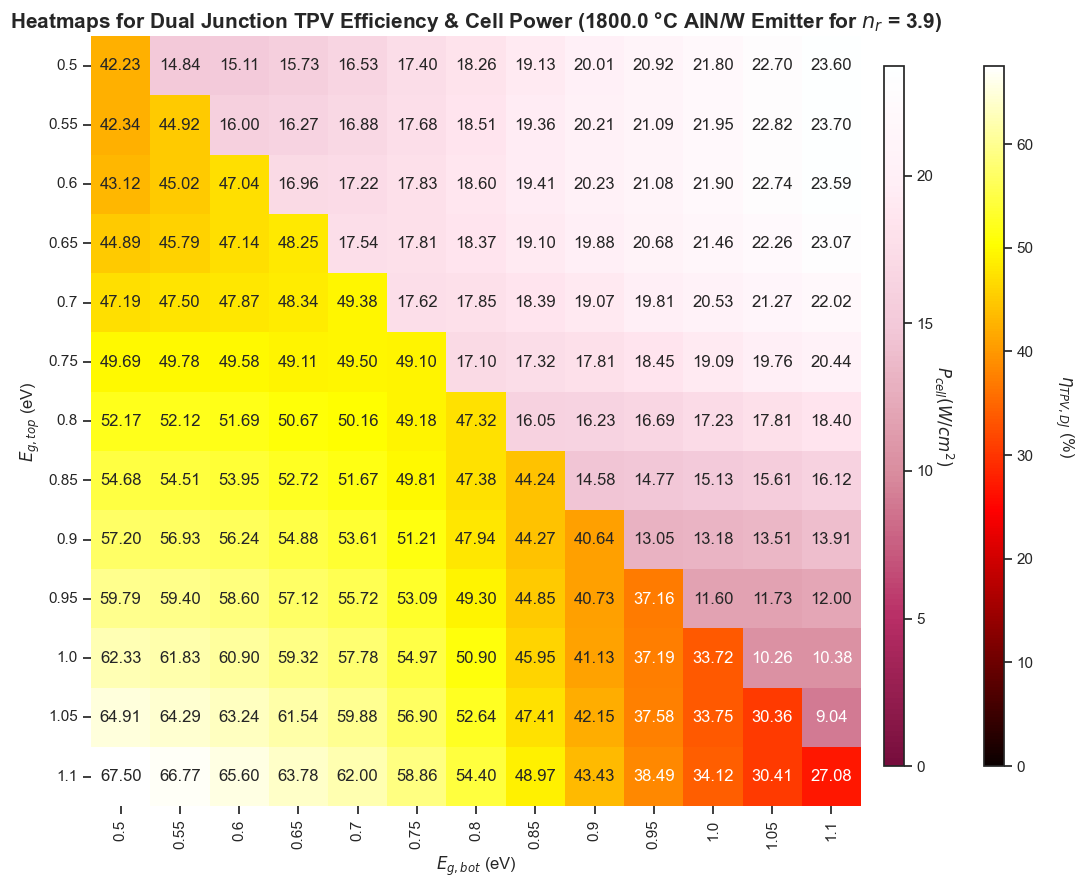

In [65]:
"""
Section 4: Creating the Heatmap 
"""

"""
heat_map() is the function that creates the heatmaps. 
see more @ https://seaborn.pydata.org/generated/seaborn.heatmap.html#seaborn.heatmap



heatmap(data, *, vmin=None, vmax=None, cmap=None, center=None, robust=False, annot=None, fmt='.2g', annot_kws=None, linewidths=0, linecolor='white', cbar=True, cbar_kws=None, cbar_ax=None, 
        #square=False, xticklabels='auto', yticklabels='auto', mask=None, ax=None, **kwargs)

"""

import seaborn as sns 
from matplotlib import cm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.colors import ListedColormap

newcolors = plt.get_cmap('PiYG', 256)(np.linspace(0, .48, 256))

for i in range(0,len(newcolors)):
    newcolors[i,0] = min(.027+newcolors[i,0]**1.4,1)
    newcolors[i,1] = min(.046+newcolors[i,1]**.9,1)
    newcolors[i,2] = min(.057+newcolors[i,2]**1.5,1)
    
newcmp = ListedColormap(newcolors) #updated colormap with 'newcolors' and this is a specific colormap, not a string defining the name of the cmap, so don't put quotes 



#actual plotting 


sns.set_theme(style = 'ticks')            #by default it has its own ticks unless you specify what kind of background you want 
fig, ax = plt.subplots(figsize = (10,10)) #I only need one ax because both heatmaps are going on the same ax



"""
To create this specific heatmap, I needed to do the following

1) Take the transpose of the P_cell_grid, so that way all of the values get repositioned to the upper right triangle/upper right corner

2) I needed to mask all the empty squares in the P_cell_grid transpose and the efficiency_grid. 

3) Plot both of them on the same ax(i.e. same plot) 

to better understand the mask, read it inside out

mask = np.triu(np.ones_like(efficiency_grid, dtype = bool), k = 1)
    - np.ones_like(efficiency_grid, dtype = bool) --> creates an array of ones that has the same dimensions as efficiency grid, but the data-type of each entry is a boolean.
    - booleans are 1's and 0's.
    - 1's --> True, 0 --> false 
    - So np.ones_like(efficiency_grid, dtype = bool) ends up creating an array of 'True' values 
    np.triu(A , k = B) will zero out everything from the k = B row and onward of your A-array. So now the array is full of true-false values, and this mask gets fed to the function

mask = np.tril(np.ones_like(P_cell_grid.T, dtype = bool), k = 0)

this all gets plotted onto ax, fig is the canvas 

"""

#Testing to see if these match up 
k = 0                                   #k is the index of the specific temperature in T_emitter that I want to call 

efficiency_grid = efficiency_ALLTEMP[k]
P_cell_grid = P_cell_ALLTEMP[k]

#######################################


sns.heatmap(efficiency_grid, vmin = 0, vmax = np.max(efficiency_grid), cmap = 'hot', xticklabels = np.round(Eg_Array,2), yticklabels = np.round(Eg_Array,2), annot = True, mask = np.triu(np.ones_like(efficiency_grid, dtype = bool), k = 1), fmt = '.2f', ax = ax, cbar = False, square = True)


sns.heatmap(P_cell_grid.T, vmin = 0, vmax = np.max(P_cell_grid.T), cmap = newcmp, xticklabels = np.round(Eg_Array,2), yticklabels = np.round(Eg_Array,2), annot = True, mask = np.tril(np.ones_like(P_cell_grid.T, dtype = bool), k = 0) , fmt = '.2f', ax = ax, cbar = False, square = True)
                    #plots the heatmap on its own ticks


# Colorbar for P_cell
sm_pcell = ScalarMappable(cmap = newcmp, norm=Normalize(vmin=0, vmax=np.max(P_cell_grid.T))) #basically defines the input of the colorbar. 
cbar_ax1 = fig.add_axes([0.92, 0.15, 0.02, 0.7])                                             #position of the colorbar [left, bottom, width, height] in figure coords
P_cell_CBAR = fig.colorbar(sm_pcell, cax=cbar_ax1)                                           #plotting the colorbar onto the figure using the input, sm_pcell, and the location, cbar_ax1 
P_cell_CBAR.set_label(r'$P_{cell} (W/cm^{2})$', rotation = 270, labelpad = 15)               #labeling the color bar 

# Colorbar for efficiency
sm_eff = ScalarMappable(cmap='hot', norm=Normalize(vmin=0, vmax=np.max(efficiency_grid)))
cbar_ax2 = fig.add_axes([1.02, 0.15, 0.02, 0.7])  
eta_CBAR = fig.colorbar(sm_eff, cax=cbar_ax2)
eta_CBAR.set_label(r'$\eta_{TPV, DJ}$ (%)', rotation = 270, labelpad = 30) 


ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)
ax.set_yticklabels(ax.get_yticklabels(), rotation = 0)

ax.set_ylabel(r'$E_{g, top}$ (eV)') 
ax.set_xlabel(r'$E_{g, bot}$ (eV)') 


ax.set_title(rf'Heatmaps for Dual Junction TPV Efficiency & Cell Power ({np.round(T_emitter[k]-273.15,0)} °C AlN/W Emitter for $n_{{r}}$ = {n_r})', fontsize = 15, fontweight = 'bold')



plt.show()